# Single-Omics Baseline (Gene Expression)

The single-omics baseline for the 3-way comparison — Elastic-Net Cox, Random Survival Forest and XGBoost trained on gene expression alone, evaluated on the **fixed reference cohort and CV folds**.

## 1. Imports

In [1]:
import os
print(os.getcwd())

c:\Users\sshor\Downloads


In [2]:
import sys
sys.path.append(r"C:\Users\sshor\Desktop\Data Science\NEWPROJECT\ML Scripts")
import common_utils as cu

In [3]:
os.chdir(r"C:\Users\sshor\Desktop\Data Science\NEWPROJECT\ML Scripts")
print(os.getcwd())  # sanity check -- should now print the ML Scripts path

C:\Users\sshor\Desktop\Data Science\NEWPROJECT\ML Scripts


In [4]:
import numpy as np


## 2. Configuration

Flipper for debug mode with a smaller subsets, keep at "false" for a true run

In [ ]:
cu.CONFIG["debug_mode"] = False   #flipper

cu.CONFIG["reference_cohort_dir"] = "reference_cohort"
EXPRESSION_FILE = "preprocessed_multiomics/expression_filtered.csv"
EXPERIMENT_NAME = "expression"


## 3. Load data

Restricted automatically to the fixed reference cohort + folds.

In [6]:
X, y, fold_arr, samples, feature_names = cu.load_reference_cohort(feature_file=EXPRESSION_FILE)


Loaded 318 samples x 5000 features, 5 folds.


## 4. Run cross-validation

Elastic-Net Cox, Random Survival Forest and XGBoost, evaluated out-of-fold on the fixed CV splits.

In [7]:
results = cu.run_cross_validation(X, y, fold_arr, models=("coxnet", "rsf", "xgboost"))


[fold 0] coxnet   C-index=0.602  IBS=0.186  (alpha=0.05495)
[fold 0] rsf      C-index=0.594  IBS=0.168
[fold 0] xgboost  C-index=0.627  IBS=0.181
[fold 1] coxnet   C-index=0.598  IBS=0.226  (alpha=0.06341)
[fold 1] rsf      C-index=0.686  IBS=0.153
[fold 1] xgboost  C-index=0.677  IBS=0.196
[fold 2] coxnet   C-index=0.770  IBS=0.262  (alpha=0.002726)
[fold 2] rsf      C-index=0.792  IBS=0.136
[fold 2] xgboost  C-index=0.800  IBS=0.154
[fold 3] coxnet   C-index=0.734  IBS=0.145  (alpha=0.05219)
[fold 3] rsf      C-index=0.738  IBS=0.138
[fold 3] xgboost  C-index=0.686  IBS=0.163
[fold 4] coxnet   C-index=0.685  IBS=nan  (alpha=0.006191)
[fold 4] rsf      C-index=0.816  IBS=0.145
[fold 4] xgboost  C-index=0.797  IBS=0.171


## 5. Summary and comparison plot

In [8]:
cu.summarize_results(results)



=== Cross-validated performance (mean +/- std across folds) ===
coxnet    C-index = 0.678 +/- 0.069   IBS = 0.205 +/- 0.044  (1 fold(s) had unstable IBS, excluded)
rsf       C-index = 0.725 +/- 0.080   IBS = 0.148 +/- 0.012
xgboost   C-index = 0.718 +/- 0.069   IBS = 0.173 +/- 0.015


Saved model_comparison_expression.png


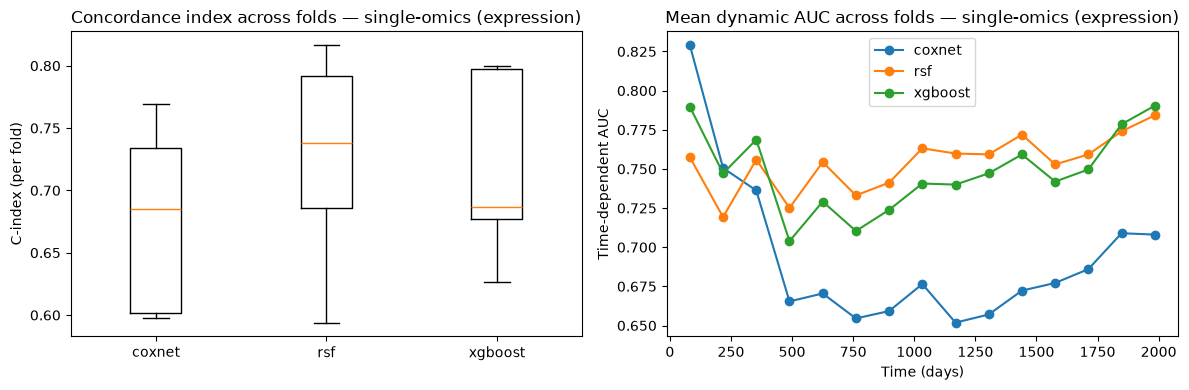

In [9]:
cu.plot_comparison(results, title_suffix=" — single-omics (expression)",
                    save_path=f"model_comparison_{EXPERIMENT_NAME}.png")


## 6. Feature importance

Refits both models on the full dataset for a final set of top features.

Elastic-Net Cox (full-data refit): alpha=0.002957, 283 nonzero features out of 5000


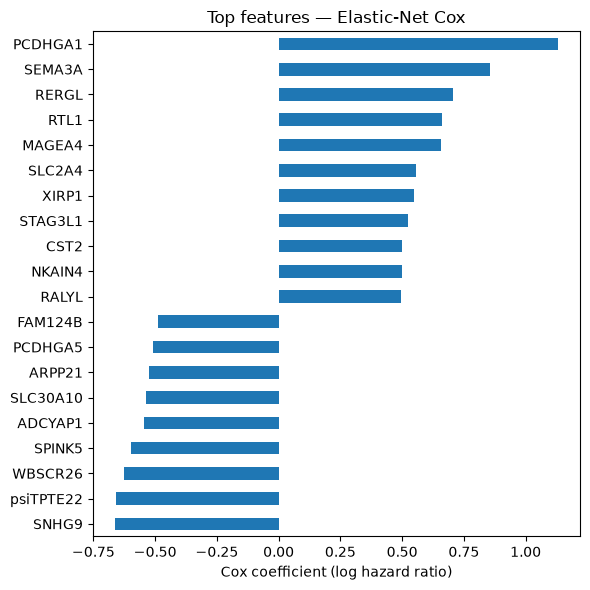

In [11]:
nonzero_coefs = cu.feature_importance_coxnet(X, y, feature_names, save_prefix=EXPERIMENT_NAME)


RSF permutation importance computed on top 300 (by variance) of 5000 total features.


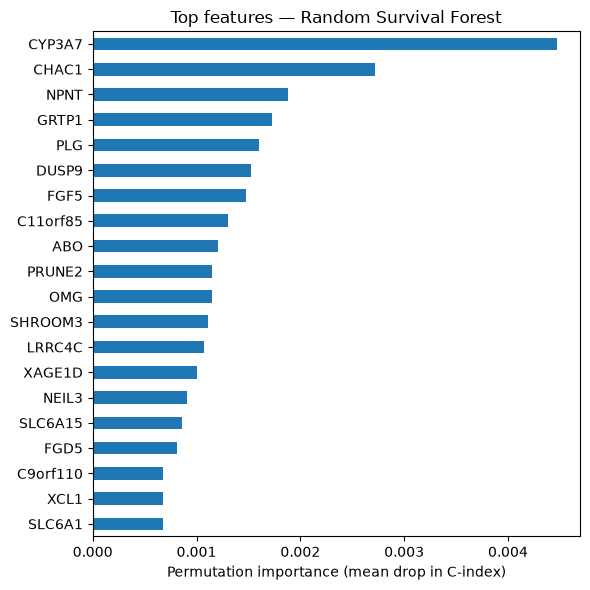

In [12]:
importances_rsf = cu.feature_importance_rsf(X, y, feature_names, save_prefix=EXPERIMENT_NAME)


XGBoost-Cox (full-data refit): 480 features with nonzero importance out of 5000


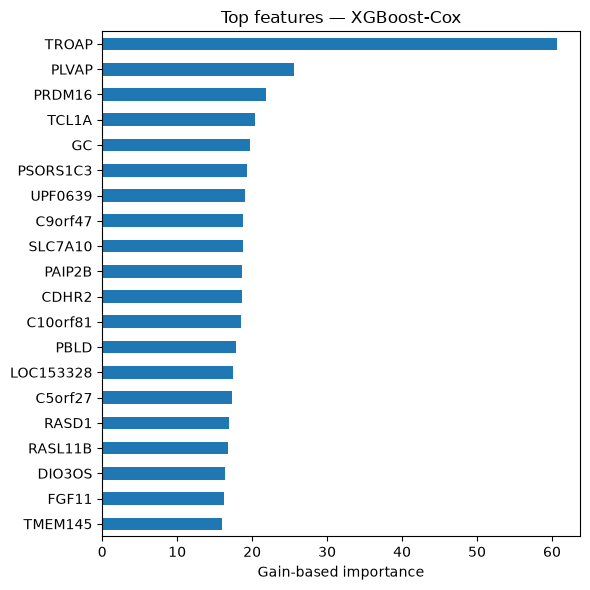

In [13]:
xgb_importances = cu.feature_importance_xgboost(X, y, feature_names, save_prefix=EXPERIMENT_NAME)

## 7. Save results for the final 3-way comparison (notebook 04)

In [14]:
cu.save_results(EXPERIMENT_NAME, results)


Saved results to results\results_expression.pkl
